# Write a manifest

> Build the small JSON document that describes a compiled kernel, and watch
> raptor refuse every way of getting it wrong.

**Time:** ~5 min · **Runs on:** CPU, no GPU needed · **You need:**
[What the contracts buy you](01_what_the_contracts_buy_you)

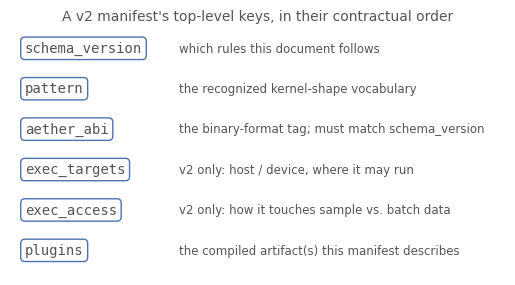

In [1]:
import sys; sys.path.insert(0, "../_shared")
from nb_diagrams import manifest_key_gloss
manifest_key_gloss()


## The code

`raptor.schema.validate_manifest` checks the manifest dict's *shape* — never
whether the artifact it names actually exists or runs. The cells below walk
through what counts as a valid shape, one rule at a time, starting with the
simplest manifest that passes:

In [2]:
from raptor.schema import validate_manifest

v1 = {
    "schema_version": 1,
    # pattern: which kind of kernel this is; "pure" = no side effects
    "pattern": "pure",
    "aether_abi": "aether-abi/1",
    # format "ptx": NVIDIA's GPU assembly format
    "plugins": [{"name": "two_body_step", "format": "ptx"}],
}
validate_manifest(v1)
print("v1 OK")

v1 OK


No exception, and nothing printed but the OK — a v1 manifest carries none of schema v2's execution-axis keys.


Schema v2 adds the execution axis — `exec_targets`/`exec_access` — as two more top-level keys, still validated the same way:


In [3]:
v2 = {
    "schema_version": 2,
    "pattern": "pure",
    "aether_abi": "aether-abi/2",
    "exec_targets": ["host", "device"],
    # sample_local: touches only this one sample's own data
    "exec_access": "sample_local",
    "plugins": [{"name": "two_body_step", "format": "ptx"}],
}
validate_manifest(v2)
print("v2 OK")

v2 OK


Both versions load today: v2 is additive, never a replacement for v1.


Three ways to get it wrong, and the exact refusal each one gets. First: a v1 document may not carry a v2 execution key.


In [4]:
bad_v1 = dict(v1, exec_targets=["host"])
try:
    validate_manifest(bad_v1)
except ValueError as exc:
    print("rejected (v1 + exec key):", exc)


rejected (v1 + exec key): '<document>': schema v1 must not carry execution key(s) ['exec_targets'] (the execution axis is schema-v2-only; set schema_version=2 and aether_abi='aether-abi/2' to use it)


The version tag alone decides which keys are legal — `exec_targets` on a v1 document is a breach, not an upgrade hint.


Second: the top-level keys are contractual *in order* — `plugins` may not come before the execution axis:


In [5]:
reordered = {
    "schema_version": 2, "pattern": "pure", "aether_abi": "aether-abi/2",
    "plugins": v2["plugins"], "exec_targets": v2["exec_targets"],
    "exec_access": v2["exec_access"],
}
try:
    validate_manifest(reordered)
except ValueError as exc:
    print("rejected (wrong key order):", exc)


rejected (wrong key order): manifest top-level key order violates the key-order contract: got ['schema_version', 'pattern', 'aether_abi', 'plugins', 'exec_targets', 'exec_access'], expected ['schema_version', 'pattern', 'aether_abi', 'exec_targets', 'exec_access', 'plugins']


Same keys, same values, wrong order — rejected, because the order itself is part of the contract.


Third: a schema version this **loader** (the code that reads and checks a
manifest) does not understand is refused outright — **forward-strict**
(refuses anything newer than it knows, rather than guessing what it means),
never a silent best-effort parse:

In [6]:
too_new = dict(v1, schema_version=7)
try:
    validate_manifest(too_new)
except ValueError as exc:
    print("rejected (future version):", exc)


rejected (future version): '<document>' was built for plugin schema v7, but this loader supports v2; upgrade eagle to load it


A future version is a hard refusal, not a guess at what it might mean.


## What just happened

- A manifest is validated for *shape* — key order, version, and the
  execution axis's vocabulary — not for whether the artifact it names
  actually exists or runs.
- Getting any one of those three things wrong raises a `ValueError` that
  names exactly what was wrong, rather than silently loading a
  best-effort guess.
- `schema_version` 1 and 2 both load today — v2 only adds flat keys for
  *where* and *how* a kernel body may run; it never replaces v1.

In practice you will not hand-write this dict: hawk's own writer,
`hawk.artifact.write_manifest`, emits one in the correct order from a
compiled kernel directly (see hawk's
[Your first kernel](https://amasat01.github.io/hawk/content/tutorials/01_your_first_kernel.html)).

## Try this

Drop the `aether_abi` key from `v2` entirely and validate it again — absence
is fine (the field is optional); only a *wrong* tag for the declared version
is refused.

## Next

[Implement a protocol](03_implement_a_protocol) covers the other half of the
contract: the shapes an engine or kernel provider must have. Deeper:
[Interoperability](/content/interop_protocols).